In [1]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
test_sample = "7_bidisperse_5_4.9/"
# test_sample = "7_2/"
# 
if os.path.isdir(test_sample):
    os.system("rm -r {}".format(test_sample))
os.system("cp -r init/{} {}".format(test_sample,test_sample))
dir = test_sample
file = "minimized.txt"

alpha = 0.02
tissue = PeriodicTissue.from_config(dir,file)
training_instance = Patterns.periodic_tissue(tissue)
training_instance.set_tolerance(1e-5)
training_instance.set_random_target_cells(n_cells=5)
# training_instance.set_central_target_cells(n_cells=5)

for cellID in training_instance._target_cell_to_stress:
    sign = np.random.choice([-1, 1])
    initial_stress = stress.calculate_max_shear_stress(training_instance._config, cellID)
    training_instance._target_cell_to_stress[cellID] = np.round((1+sign*alpha) * initial_stress,3)
    # training_instance._target_cell_to_stress[cellID] = alpha
    print("Initial stress for cell {}: {}".format(cellID, initial_stress))
print(training_instance._target_cell_to_stress)
training_instance.run()



Initial stress for cell 338: 0.1886800512773963
Initial stress for cell 114: 0.407649474787509
Initial stress for cell 238: 0.49740351592644405
Initial stress for cell 133: 0.32253802848139657
Initial stress for cell 249: 0.20686347330681376
{338: np.float64(0.198), 114: np.float64(0.428), 238: np.float64(0.522), 133: np.float64(0.339), 249: np.float64(0.217)}
Initial Cost: 1.48e-03




Starting iteration: 0




Number of modifiable cells: 343


-------------------------------------
Step 1: Evaluate and store the current (free state) areas of hidden (non-target) cells


-------------------------------------
Step 2: CLAMPING
Clamping iteration 0
Cell: 338, Final Target Stress: 0.198 Temporary Target Stress: 0.21645349847075535, Current stress: 0.1886800512773963, s0: 5.0
Cell: 114, Final Target Stress: 0.428 Temporary Target Stress: 0.5151002479094613, Current stress: 0.407649474787509, s0: 5.0
Cell: 238, Final Target Stress: 0.522 Temporary Target Stress: 0.6503936468639622, Current st

LinAlgError: Eigenvalues did not converge

In [9]:
import pandas as pd
dic = {0:1,1:2}
df = pd.DataFrame(dic.items(), columns=['cellID', 'target_stress'])
print(df)

   cellID  target_stress
0       0              1
1       1              2


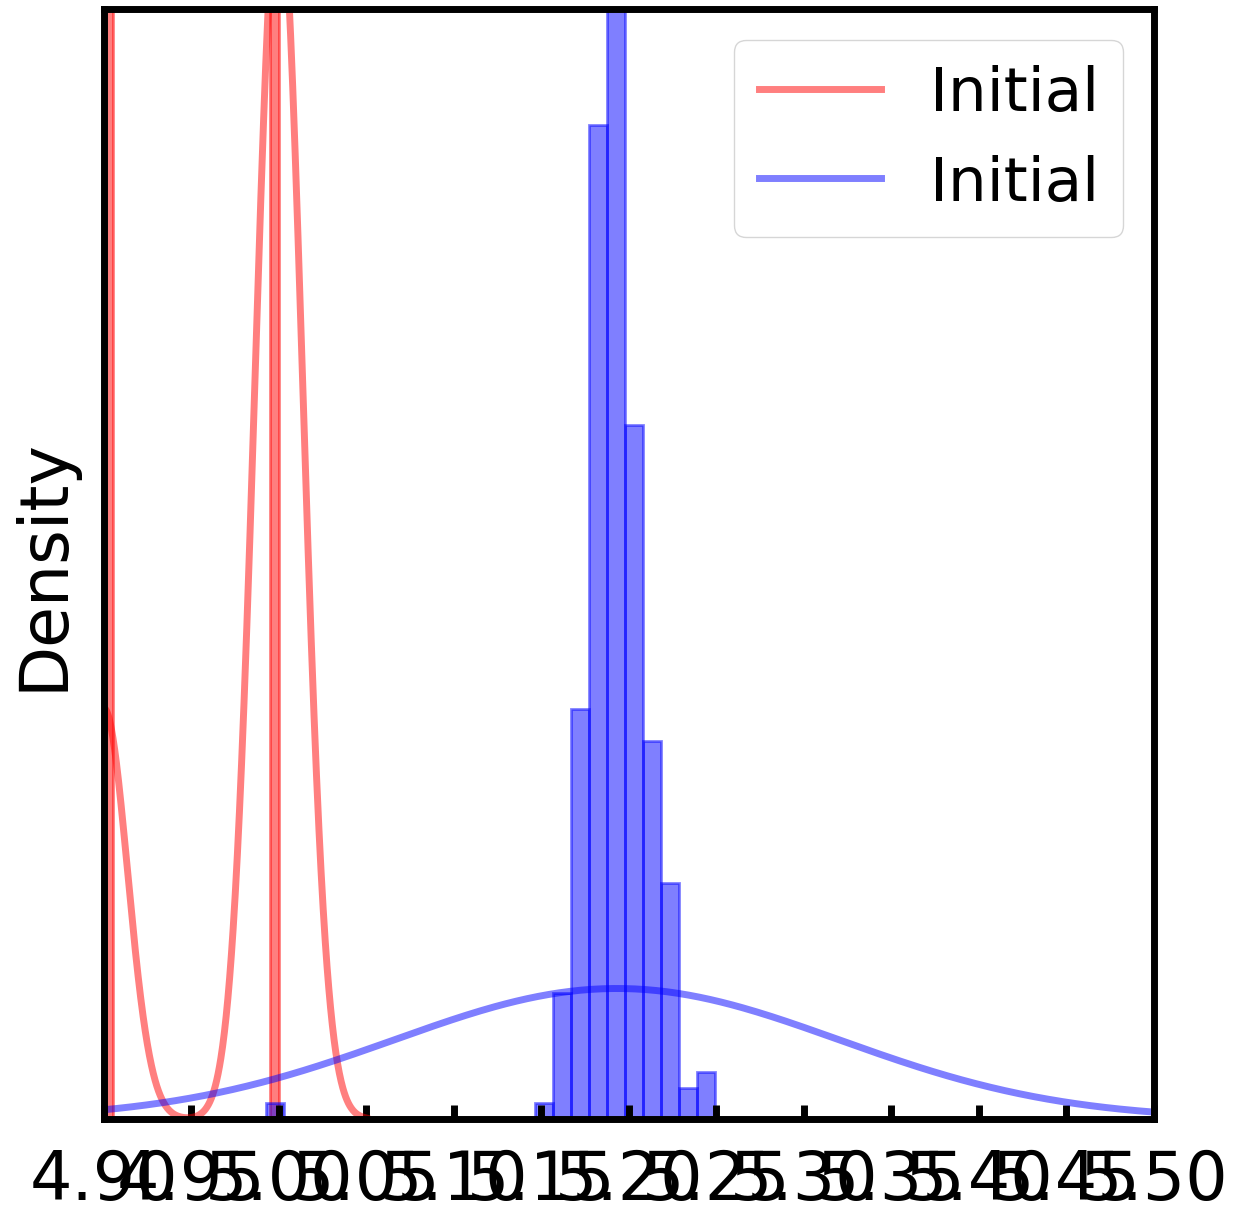

In [9]:
import pandas as pd
from toolbox import manuscriptPlots

dir = "7_bidisperse_5_4.9_success/"
final_iter = 14
iter_to_labels = {0:"Initial", 15:"Trained"}
iter_to_colors = {0:"blue", 15:"red"}
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,20)
plotter.set_xlim(4.9,5.5)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel(r"$s_0$")
plotter.set_xticks([4.9+0.05*i for i in range(50)])
plotter.set_yticks([100*i for i in range(1,100)])
plotter.set_yScaled()
plotter.initialize_figure()
#init
df = pd.read_csv("{}/cellParameters.init.input".format(dir), sep=" ",header=None)
plotter.histogram_from_dataframe(df[2],color = "red", bins = 20, label = "Initial")
df = pd.read_csv("{}/cellParameters.{}.input".format(dir,final_iter), sep=" ",header=None)
plotter.histogram_from_dataframe(df[2],color = "blue", bins = 100, label = "Initial")

plotter.save_fig("{}/s0_histogram.jpg".format(dir))


Cell ID: 0, s0: 5.0, crossBoundary False, stress 0.17148424085163105
Cell ID: 1, s0: 5.0, crossBoundary True, stress 0.2792882551450573
Cell ID: 2, s0: 5.0, crossBoundary True, stress 0.24880395739978978
Cell ID: 3, s0: 5.0, crossBoundary True, stress 0.45017308790112187
Cell ID: 4, s0: 5.0, crossBoundary True, stress 0.1652069918353416
Cell ID: 5, s0: 5.0, crossBoundary True, stress 0.4523802339837859
Cell ID: 6, s0: 5.0, crossBoundary True, stress 0.21868821683747486
Cell ID: 7, s0: 5.0, crossBoundary False, stress 0.30338692515096066
Cell ID: 8, s0: 5.0, crossBoundary False, stress 0.16036306206374595
Cell ID: 9, s0: 5.0, crossBoundary True, stress 0.23602577168293348
Cell ID: 10, s0: 5.0, crossBoundary False, stress 0.29172784625435
Cell ID: 11, s0: 5.0, crossBoundary False, stress 0.330018622169685
Cell ID: 12, s0: 5.0, crossBoundary True, stress 0.23861860656615197
Cell ID: 13, s0: 5.0, crossBoundary True, stress 0.3848362058914696
Cell ID: 14, s0: 5.0, crossBoundary False, stres

(array([ 1.,  0.,  1.,  3.,  4., 12.,  5.,  7., 12.,  7.,  8., 14.,  8.,
        21., 12., 19., 18.,  9., 15., 17., 16., 13., 15.,  8., 17.,  7.,
        11., 12., 12.,  9.,  2.,  4.,  3.,  4.,  4.,  4.,  3.,  1.,  1.,
         0.,  1.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  1.]),
 array([0.04641208, 0.06112886, 0.07584564, 0.09056242, 0.1052792 ,
        0.11999598, 0.13471276, 0.14942954, 0.16414632, 0.1788631 ,
        0.19357988, 0.20829666, 0.22301344, 0.23773022, 0.25244701,
        0.26716379, 0.28188057, 0.29659735, 0.31131413, 0.32603091,
        0.34074769, 0.35546447, 0.37018125, 0.38489803, 0.39961481,
        0.41433159, 0.42904837, 0.44376515, 0.45848193, 0.47319871,
        0.48791549, 0.50263227, 0.51734905, 0.53206583, 0.54678262,
        0.5614994 , 0.57621618, 0.59093296, 0.60564974, 0.62036652,
        0.6350833 , 0.64980008, 0.66451686, 0.67923364, 0.69395042,
        0.7086672 , 0.72338398, 0.73810076, 0.75281754, 0.76753432,
        0.7822511 ]),
 <BarContainer

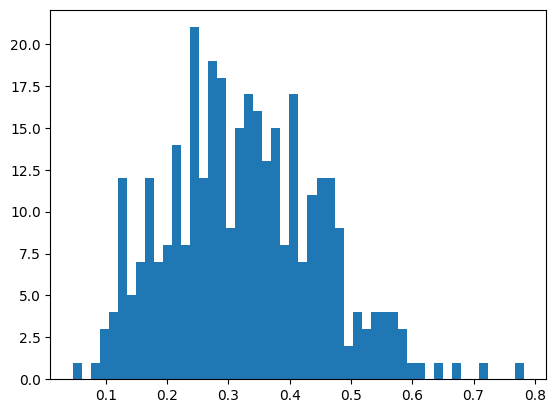

In [1]:
from toolbox.periodic import PeriodicTissue
from toolbox import stress
import matplotlib.pyplot as plt
dir = "7_bidisperse_5_4.9_success/"
file = "14.bulk.txt"

tissue = PeriodicTissue.from_config(dir, file)
stresses = []
for cellID,cell in tissue.cells_.items():
    max_shear_stress = stress.calculate_max_shear_stress(tissue, cellID)
    stresses.append(max_shear_stress)
    print("Cell ID: {}, s0: {}, crossBoundary {}, stress {}".format(cellID, cell.s0_, cell.crossBoundary_, max_shear_stress))
plt.hist(stresses, bins=50)

In [2]:
import numpy as np

np.round(0.5343234234324,2)

np.float64(0.53)